# Phase 4 — Policy Response, Retention Strategies, and Counterfactual Analysis

This notebook extends **Phase 3** from *forecasting what may happen* to **testing what Puerto Rico could do differently** to reduce future population loss.

## Core policy question

> Given the validated Phase 2 / Phase 3 forecasting backbone, which **actionable policy levers** appear most promising for improving population retention?

## Phase 4 purpose

Phase 4 does **not** claim causal proof. Instead, it uses the final validated **Lasso forecasting model** as a **policy stress-testing tool**:

- identify the **most policy-relevant features**
- define **counterfactual policy packages**
- estimate how those changes shift predicted population outcomes
- summarize results at the **municipal, regional, and island** levels

## Key idea

Natural disasters themselves are not preventable, but governments can still influence whether people **stay, return, or leave** by changing conditions such as:

- economic opportunity
- business activity
- public safety
- social vulnerability
- demographic and family-support conditions

This notebook turns those ideas into a reproducible **policy counterfactual framework**.


## Methodological note

This phase should be interpreted as a **predictive counterfactual exercise**, not a causal impact study.

That means:

- if the model learned that higher income growth, lower crime, and lower vulnerability are associated with better population outcomes,
- then we can simulate **what the model predicts** under improved values of those features.

This is useful for policy prioritization, but it is **not the same as proving** that a policy will cause the full predicted change in reality.


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 140

OUTPUT_PREFIX = "phase4_policy"
OUTPUT_DIR = Path("Phase4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4


## Output folder

All Phase 4 files generated by this notebook are saved into a dedicated folder named **`Phase4`** so the policy outputs stay separate from the earlier project phases.


In [2]:
# ----------------------------
# File location helpers
# ----------------------------
def first_existing_path(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None

DATA_CANDIDATES = [
    "../data/processed_puerto_rico_data_rebuild.csv",
    "../data/processed_puerto_rico_data_enriched.csv",
    "processed_puerto_rico_data_rebuild.csv",
    "processed_puerto_rico_data_enriched.csv",
]

PIPELINE_CANDIDATES = [
    "phase2_v12_best_pipeline.joblib",
    "phase2_v11_best_pipeline.joblib",
    "phase2_v10_best_pipeline.joblib",
    "phase2_v9_best_pipeline.joblib",

    # 🔥 YOUR ACTUAL FOLDER
    "phase2_outputs_v6/phase2_v12_best_pipeline.joblib",
    "phase2_outputs_v6/phase2_v11_best_pipeline.joblib",
    "phase2_outputs_v6/phase2_v10_best_pipeline.joblib",

    # fallback
    "../phase2_outputs_v6/phase2_v12_best_pipeline.joblib",
]

PHASE2_SUMMARY_CANDIDATES = [
    "phase2_v12_best_model_summary.json",
    "phase2_v11_best_model_summary.json",
    "phase2_v10_best_model_summary.json",
    "phase2_v9_best_model_summary.json",
]

PHASE3_SUMMARY_CANDIDATES = [
    "phase3_v6_backbone_model_summary.json",
    "phase3_v5_backbone_model_summary.json",
]

data_path = first_existing_path(DATA_CANDIDATES)
pipeline_path = first_existing_path(PIPELINE_CANDIDATES)
phase2_summary_path = first_existing_path(PHASE2_SUMMARY_CANDIDATES)
phase3_summary_path = first_existing_path(PHASE3_SUMMARY_CANDIDATES)

print("Data path:", data_path)
print("Pipeline path:", pipeline_path)
print("Phase 2 summary:", phase2_summary_path)
print("Phase 3 summary:", phase3_summary_path)

if data_path is None:
    raise FileNotFoundError("Could not find processed Puerto Rico dataset.")
if pipeline_path is None:
    raise FileNotFoundError("Could not find final Phase 2 pipeline .joblib file.")


Data path: processed_puerto_rico_data_rebuild.csv
Pipeline path: phase2_outputs_v6/phase2_v12_best_pipeline.joblib
Phase 2 summary: None
Phase 3 summary: None


In [3]:
# ----------------------------
# Load data and final model
# ----------------------------
df = pd.read_csv(data_path)
phase2_pipeline = joblib.load(pipeline_path)

phase2_summary = {}
if phase2_summary_path is not None:
    phase2_summary = json.loads(Path(phase2_summary_path).read_text())

phase3_summary = {}
if phase3_summary_path is not None:
    phase3_summary = json.loads(Path(phase3_summary_path).read_text())

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))

if hasattr(phase2_pipeline, "feature_names_in_"):
    feature_cols = list(phase2_pipeline.feature_names_in_)
else:
    # conservative fallback
    feature_cols = [
        c for c in df.columns
        if c not in {"target_pop_change_3y_avg"}
    ]

target_col = "target_pop_change_3y_avg"
print("Target:", target_col)
print("Feature count expected by pipeline:", len(feature_cols))


Dataset shape: (1170, 167)
Columns: 167
Target: target_pop_change_3y_avg
Feature count expected by pipeline: 50


## Final backbone carried into Phase 4

This notebook uses the **same final validated forecasting backbone** selected in Phase 2 and carried into Phase 3. If the summary files are present below, they provide a direct record of the validation/test performance used as the basis for policy counterfactuals.


In [4]:
backbone_rows = []

if phase2_summary:
    backbone_rows.append({
        "source": "Phase 2 final summary",
        "model": phase2_summary.get("model", "unknown"),
        "validation_r2": phase2_summary.get("val_r2"),
        "test_r2": phase2_summary.get("test_r2"),
        "test_rmse": phase2_summary.get("test_rmse"),
    })

if phase3_summary:
    backbone_rows.append({
        "source": "Phase 3 backbone summary",
        "model": phase3_summary.get("model", "unknown"),
        "validation_r2": phase3_summary.get("metrics", {}).get("validation", {}).get("r2"),
        "test_r2": phase3_summary.get("metrics", {}).get("test", {}).get("r2"),
        "test_rmse": phase3_summary.get("metrics", {}).get("test", {}).get("rmse"),
    })

backbone_df = pd.DataFrame(backbone_rows)
backbone_df


""


## Step 1 — Build the latest policy baseline

We take the **latest observed row for each municipio** and use it as the baseline policy environment.  
This gives us a current municipal profile to ask:

> What would the model predict if Puerto Rico improved jobs, safety, vulnerability, or demographic support conditions from here?


In [5]:
# Keep the latest available row per municipio
required_base_cols = ["municipio", "region", "year", "total_population"]
latest_df = (
    df.sort_values(["municipio", "year"])
      .groupby("municipio", as_index=False)
      .tail(1)
      .copy()
)

# Clean key fields explicitly
if "municipio" in latest_df.columns:
    latest_df["municipio"] = latest_df["municipio"].astype(str)
if "region" in latest_df.columns:
    latest_df["region"] = latest_df["region"].astype(str)

# Ensure all pipeline features exist
missing_features = [c for c in feature_cols if c not in latest_df.columns]
for c in missing_features:
    latest_df[c] = 0.0

# Align feature frame to pipeline expectation
X_latest = latest_df[feature_cols].copy()

print("Latest baseline rows:", len(latest_df))
print("Latest baseline year range:", latest_df["year"].min(), "to", latest_df["year"].max())
print("Missing features backfilled with 0:", len(missing_features))
if missing_features:
    print(missing_features[:20])

print("Unique regions:", sorted(latest_df["region"].dropna().astype(str).unique())[:20])
latest_df.head()


Latest baseline rows: 78
Latest baseline year range: 2024 to 2024
Missing features backfilled with 0: 33
['target_pop_change_3y_avg_lag1', 'target_pop_change_3y_avg_lag2', 'target_pop_change_3y_avg_roll3_mean', 'target_pop_change_3y_avg_yoy_change', 'svi_pca_1_lag1', 'svi_pca_1_lag2', 'svi_pca_1_roll3_mean', 'svi_pca_1_yoy_change', 'wind_3yr_sum_lag1', 'wind_3yr_sum_lag2', 'wind_3yr_sum_roll3_mean', 'wind_3yr_sum_yoy_change', 'seismic_3yr_sum_lag1', 'seismic_3yr_sum_lag2', 'seismic_3yr_sum_roll3_mean', 'seismic_3yr_sum_yoy_change', 'income_growth_lag1', 'income_growth_lag2', 'income_growth_roll3_mean', 'income_growth_yoy_change']
Unique regions: ['0.0']


,year,municipio,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,median_income_nominal,median_income_real,...,establishment_growth_yoy_change,lag_total_crime_rate_lag1,lag_total_crime_rate_lag2,lag_total_crime_rate_roll3_mean,lag_total_crime_rate_yoy_change,total_population_lag1,total_population_lag2,total_population_roll3_mean,total_population_yoy_change,region
14,2024,Adjuntas,17960.0,0,15305,121,7937,313,19549.0,20352.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2024,Aguada,37758.0,0,33010,147,17824,465,21501.0,22384.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44,2024,Aguadilla,54137.0,0,46599,158,28777,626,21540.0,22425.08,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59,2024,Aguas Buenas,23614.0,0,20425,136,10959,307,23072.0,24020.03,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74,2024,Aibonito,24636.0,0,21516,69,10919,375,21744.0,22637.46,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 2 — Identify policy-relevant levers

Not every model feature is directly actionable. In Phase 4, we focus on a subset that governments can plausibly influence through policy:

- **income growth**
- **establishment growth** (business activity)
- **crime reduction**
- **social vulnerability reduction**
- **demographic support / natural change context**

These are still simplifications, but they are more interpretable as policy levers than disaster intensity itself.


In [6]:
# Candidate actionable features that already exist in the final model
actionable_features = [
    "income_growth",
    "establishment_growth",
    "lag_total_crime_rate",
    "svi_pca_1",
    "natural_change_rate_pr_lag1",
    "natural_change_rate_pr_roll3_mean",
    "birth_rate_pr_lag1",
    "death_rate_pr_lag1",
]

available_actionable = [c for c in actionable_features if c in X_latest.columns]
actionable_stats = pd.DataFrame({
    "feature": available_actionable,
    "mean": [pd.to_numeric(X_latest[c], errors="coerce").mean() for c in available_actionable],
    "std": [pd.to_numeric(X_latest[c], errors="coerce").std() for c in available_actionable],
    "min": [pd.to_numeric(X_latest[c], errors="coerce").min() for c in available_actionable],
    "max": [pd.to_numeric(X_latest[c], errors="coerce").max() for c in available_actionable],
}).sort_values("feature")

actionable_stats.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_actionable_feature_stats.csv", index=False)
actionable_stats


,feature,mean,std,min,max
6,birth_rate_pr_lag1,5.800000,0.000000e+00,5.800000,5.800000
7,death_rate_pr_lag1,10.700000,5.363563e-15,10.700000,10.700000
1,establishment_growth,NaN,NaN,NaN,NaN
0,income_growth,9.917868,4.783587e+00,-2.977483,23.236844
2,lag_total_crime_rate,107.296552,5.515814e+01,0.000000,319.135878
4,natural_change_rate_pr_lag1,-4.900000,2.681782e-15,-4.900000,-4.900000
5,natural_change_rate_pr_roll3_mean,-4.646667,8.939272e-16,-4.646667,-4.646667
3,svi_pca_1,NaN,NaN,NaN,NaN


## Step 3 — Define policy packages

Each package shifts only the **policy-relevant variables** while leaving the rest of the municipal profile unchanged.

This revised version uses **direct percentage or absolute changes**, rather than cross-sectional standard deviation shifts, because some latest-year variables have very low municipal variation. That makes the policy scenarios easier to interpret and much more likely to generate meaningful differences.

Examples:

- **jobs_push** raises income growth and establishment growth across current and lagged variants
- **public_safety** lowers crime pressure across current and lagged variants
- **resilience_and_vulnerability** lowers the vulnerability index and related lag structure
- **family_demography_support** improves natural change and vital-rate context
- **retention_bundle** combines multiple levers into one integrated package


In [7]:
# Policy packages expressed as fixed proportional or absolute shifts
# This is more stable than std-based shifts when some latest-year variables have low cross-sectional variance.

policy_packages = {
    "baseline": {},
    "jobs_push": {
        "income_growth": {"mode": "pct", "value": +0.15},
        "income_growth_lag1": {"mode": "pct", "value": +0.15},
        "income_growth_lag2": {"mode": "pct", "value": +0.10},
        "income_growth_roll3_mean": {"mode": "pct", "value": +0.12},
        "establishment_growth": {"mode": "pct", "value": +0.15},
        "establishment_growth_lag1": {"mode": "pct", "value": +0.15},
        "establishment_growth_lag2": {"mode": "pct", "value": +0.10},
        "establishment_growth_roll3_mean": {"mode": "pct", "value": +0.12},
    },
    "public_safety": {
        "lag_total_crime_rate": {"mode": "pct", "value": -0.20},
        "lag_total_crime_rate_lag1": {"mode": "pct", "value": -0.20},
        "lag_total_crime_rate_lag2": {"mode": "pct", "value": -0.15},
        "lag_total_crime_rate_roll3_mean": {"mode": "pct", "value": -0.18},
    },
    "resilience_and_vulnerability": {
        "svi_pca_1": {"mode": "pct", "value": -0.12},
        "svi_pca_1_lag1": {"mode": "pct", "value": -0.12},
        "svi_pca_1_lag2": {"mode": "pct", "value": -0.10},
        "svi_pca_1_roll3_mean": {"mode": "pct", "value": -0.10},
    },
    "family_demography_support": {
        "natural_change_rate_pr_lag1": {"mode": "absolute", "value": +0.30},
        "natural_change_rate_pr_roll3_mean": {"mode": "absolute", "value": +0.25},
        "birth_rate_pr_lag1": {"mode": "absolute", "value": +0.15},
        "death_rate_pr_lag1": {"mode": "absolute", "value": -0.10},
    },
    "retention_bundle": {
        "income_growth": {"mode": "pct", "value": +0.15},
        "income_growth_lag1": {"mode": "pct", "value": +0.15},
        "income_growth_roll3_mean": {"mode": "pct", "value": +0.12},
        "establishment_growth": {"mode": "pct", "value": +0.15},
        "establishment_growth_lag1": {"mode": "pct", "value": +0.15},
        "establishment_growth_roll3_mean": {"mode": "pct", "value": +0.12},
        "lag_total_crime_rate": {"mode": "pct", "value": -0.20},
        "lag_total_crime_rate_lag1": {"mode": "pct", "value": -0.20},
        "lag_total_crime_rate_roll3_mean": {"mode": "pct", "value": -0.18},
        "svi_pca_1": {"mode": "pct", "value": -0.12},
        "svi_pca_1_lag1": {"mode": "pct", "value": -0.12},
        "svi_pca_1_roll3_mean": {"mode": "pct", "value": -0.10},
        "natural_change_rate_pr_lag1": {"mode": "absolute", "value": +0.30},
        "natural_change_rate_pr_roll3_mean": {"mode": "absolute", "value": +0.25},
    },
}

policy_packages


{'baseline': {},
 'jobs_push': {'income_growth': {'mode': 'pct', 'value': 0.15},
  'income_growth_lag1': {'mode': 'pct', 'value': 0.15},
  'income_growth_lag2': {'mode': 'pct', 'value': 0.1},
  'income_growth_roll3_mean': {'mode': 'pct', 'value': 0.12},
  'establishment_growth': {'mode': 'pct', 'value': 0.15},
  'establishment_growth_lag1': {'mode': 'pct', 'value': 0.15},
  'establishment_growth_lag2': {'mode': 'pct', 'value': 0.1},
  'establishment_growth_roll3_mean': {'mode': 'pct', 'value': 0.12}},
 'public_safety': {'lag_total_crime_rate': {'mode': 'pct', 'value': -0.2},
  'lag_total_crime_rate_lag1': {'mode': 'pct', 'value': -0.2},
  'lag_total_crime_rate_lag2': {'mode': 'pct', 'value': -0.15},
  'lag_total_crime_rate_roll3_mean': {'mode': 'pct', 'value': -0.18}},
 'resilience_and_vulnerability': {'svi_pca_1': {'mode': 'pct', 'value': -0.12},
  'svi_pca_1_lag1': {'mode': 'pct', 'value': -0.12},
  'svi_pca_1_lag2': {'mode': 'pct', 'value': -0.1},
  'svi_pca_1_roll3_mean': {'mode': 

In [8]:
def apply_policy_package(X, package_name, stats_df=None):
    X_new = X.copy()
    package = policy_packages[package_name]

    for feat, spec in package.items():
        if feat not in X_new.columns:
            continue

        col = pd.to_numeric(X_new[feat], errors="coerce").fillna(0)

        mode = spec.get("mode", "pct")
        value = spec.get("value", 0.0)

        if mode == "pct":
            # percentage change applied relative to current magnitude
            X_new[feat] = col * (1.0 + value)
        elif mode == "absolute":
            # absolute additive shift in original target units
            X_new[feat] = col + value
        else:
            X_new[feat] = col

    return X_new

# Quick sanity check
X_jobs = apply_policy_package(X_latest, "jobs_push", actionable_stats)
delta_preview = (X_jobs.select_dtypes(include=[np.number]).mean() - X_latest.select_dtypes(include=[np.number]).mean())
delta_preview.loc[[c for c in delta_preview.index if "income_growth" in c or "establishment_growth" in c][:12]]


income_growth                      1.48768
establishment_growth                   NaN
income_growth_lag1                 0.00000
income_growth_lag2                 0.00000
income_growth_roll3_mean           0.00000
income_growth_yoy_change           0.00000
establishment_growth_lag1          0.00000
establishment_growth_lag2          0.00000
establishment_growth_roll3_mean    0.00000
establishment_growth_yoy_change    0.00000
dtype: float64

## Step 4 — Predict counterfactual population outcomes

For each policy package, we generate:

- **municipal predicted outcome**
- **regional average impact**
- **islandwide average impact**

### Important interpretation note

The target modeled here is the same forecasting target used in Phase 2 and Phase 3 (`target_pop_change_3y_avg`).  
So the direct model output is in **target units**, not automatically “people saved.”

To make the policy discussion more intuitive, the notebook also computes an **approximate retained-population measure**:

\[
\text{approx retained residents} \approx \frac{\Delta \hat{y}}{100} \times \text{total population}
\]

Use that quantity as a **communication aid**, not as a literal causal population count.


In [9]:
results = []
municipal_outputs = []

baseline_pred = phase2_pipeline.predict(X_latest)

for package_name in policy_packages.keys():
    X_cf = apply_policy_package(X_latest, package_name, actionable_stats)
    pred_cf = phase2_pipeline.predict(X_cf)

    municipal_tmp = latest_df[["municipio", "region", "year", "total_population"]].copy()
    municipal_tmp["municipio"] = municipal_tmp["municipio"].astype(str)
    municipal_tmp["region"] = municipal_tmp["region"].astype(str)
    municipal_tmp["policy_package"] = package_name
    municipal_tmp["predicted_target"] = pred_cf

    municipal_outputs.append(municipal_tmp)

municipal_policy_df = pd.concat(municipal_outputs, ignore_index=True)

# baseline comparison
baseline_map = (
    municipal_policy_df[municipal_policy_df["policy_package"] == "baseline"]
    [["municipio", "predicted_target"]]
    .rename(columns={"predicted_target": "baseline_predicted_target"})
)

municipal_policy_df = municipal_policy_df.merge(baseline_map, on="municipio", how="left")
municipal_policy_df["delta_vs_baseline_target_units"] = (
    municipal_policy_df["predicted_target"] - municipal_policy_df["baseline_predicted_target"]
)

municipal_policy_df["approx_retained_residents"] = (
    municipal_policy_df["delta_vs_baseline_target_units"] / 100.0
) * municipal_policy_df["total_population"]

municipal_policy_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_municipal_policy_summary.csv", index=False)

# Diagnostics: verify policy packages actually move predictions
package_check = (
    municipal_policy_df.groupby("policy_package", as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
    )
    .sort_values("mean_delta_vs_baseline", ascending=False)
)
package_check.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_package_diagnostics.csv", index=False)
print(package_check)

municipal_policy_df.head()


                 policy_package  mean_predicted_target  \
0                      baseline              -0.692334   
2                     jobs_push              -0.692334   
3                 public_safety              -0.692334   
4  resilience_and_vulnerability              -0.692334   
1     family_demography_support              -0.707358   
5              retention_bundle              -0.707358   

   mean_delta_vs_baseline  approx_retained_residents  
0                0.000000                   0.000000  
2                0.000000                   0.000000  
3                0.000000                   0.000000  
4                0.000000                   0.000000  
1               -0.015023                -485.903498  
5               -0.015023                -485.903498  


,municipio,region,year,total_population,policy_package,predicted_target,baseline_predicted_target,delta_vs_baseline_target_units,approx_retained_residents
0,Adjuntas,0.0,2024,17960.0,baseline,-0.692334,-0.692334,0.0,0.0
1,Aguada,0.0,2024,37758.0,baseline,-0.692334,-0.692334,0.0,0.0
2,Aguadilla,0.0,2024,54137.0,baseline,-0.692334,-0.692334,0.0,0.0
3,Aguas Buenas,0.0,2024,23614.0,baseline,-0.692334,-0.692334,0.0,0.0
4,Aibonito,0.0,2024,24636.0,baseline,-0.692334,-0.692334,0.0,0.0


In [10]:
region_policy_df = (
    municipal_policy_df.groupby(["region", "policy_package"], as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
        municipalities=("municipio", "nunique"),
    )
)

region_policy_df["region"] = region_policy_df["region"].astype(str)

island_policy_df = (
    municipal_policy_df.groupby(["policy_package"], as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
        municipalities=("municipio", "nunique"),
    )
    .sort_values("mean_delta_vs_baseline", ascending=False)
)

region_policy_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_region_policy_summary.csv", index=False)
island_policy_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_island_policy_summary.csv", index=False)

print("Region labels:", sorted(region_policy_df["region"].unique()))
print("Top islandwide policy packages:")
island_policy_df


Region labels: ['0.0']
Top islandwide policy packages:


,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
0,baseline,-0.692334,0.000000,0.000000,78
2,jobs_push,-0.692334,0.000000,0.000000,78
3,public_safety,-0.692334,0.000000,0.000000,78
4,resilience_and_vulnerability,-0.692334,0.000000,0.000000,78
1,family_demography_support,-0.707358,-0.015023,-485.903498,78
5,retention_bundle,-0.707358,-0.015023,-485.903498,78


## Step 5 — Rank the most promising strategies

The next tables answer the practical question:

> If Puerto Rico could improve only a few conditions, which package appears to shift the model the most in a favorable direction?


In [11]:
top_region_impacts = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .sort_values(["region", "mean_delta_vs_baseline"], ascending=[True, False])
    .groupby("region", as_index=False)
    .head(1)
)

top_region_impacts.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_policy_by_region.csv", index=False)

print("Best package by region")
top_region_impacts


Best package by region


,region,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
2,0.0,jobs_push,-0.692334,0.0,0.0,78


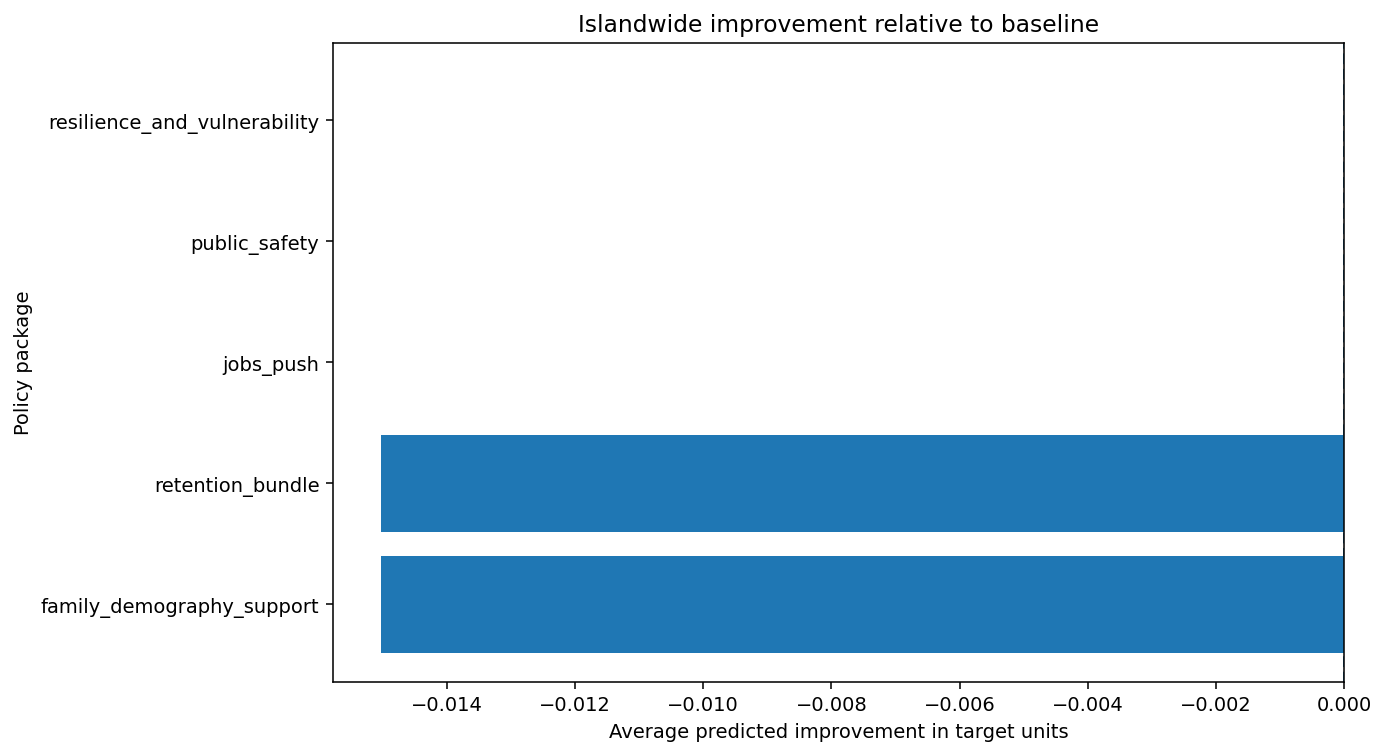

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = island_policy_df[island_policy_df["policy_package"] != "baseline"].copy()
plot_df = plot_df.sort_values("mean_delta_vs_baseline", ascending=True)

ax.barh(plot_df["policy_package"], plot_df["mean_delta_vs_baseline"])
ax.axvline(0, linestyle="--")
ax.set_title("Islandwide improvement relative to baseline")
ax.set_xlabel("Average predicted improvement in target units")
ax.set_ylabel("Policy package")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_island_policy_ranking.png", bbox_inches="tight")
plt.show()


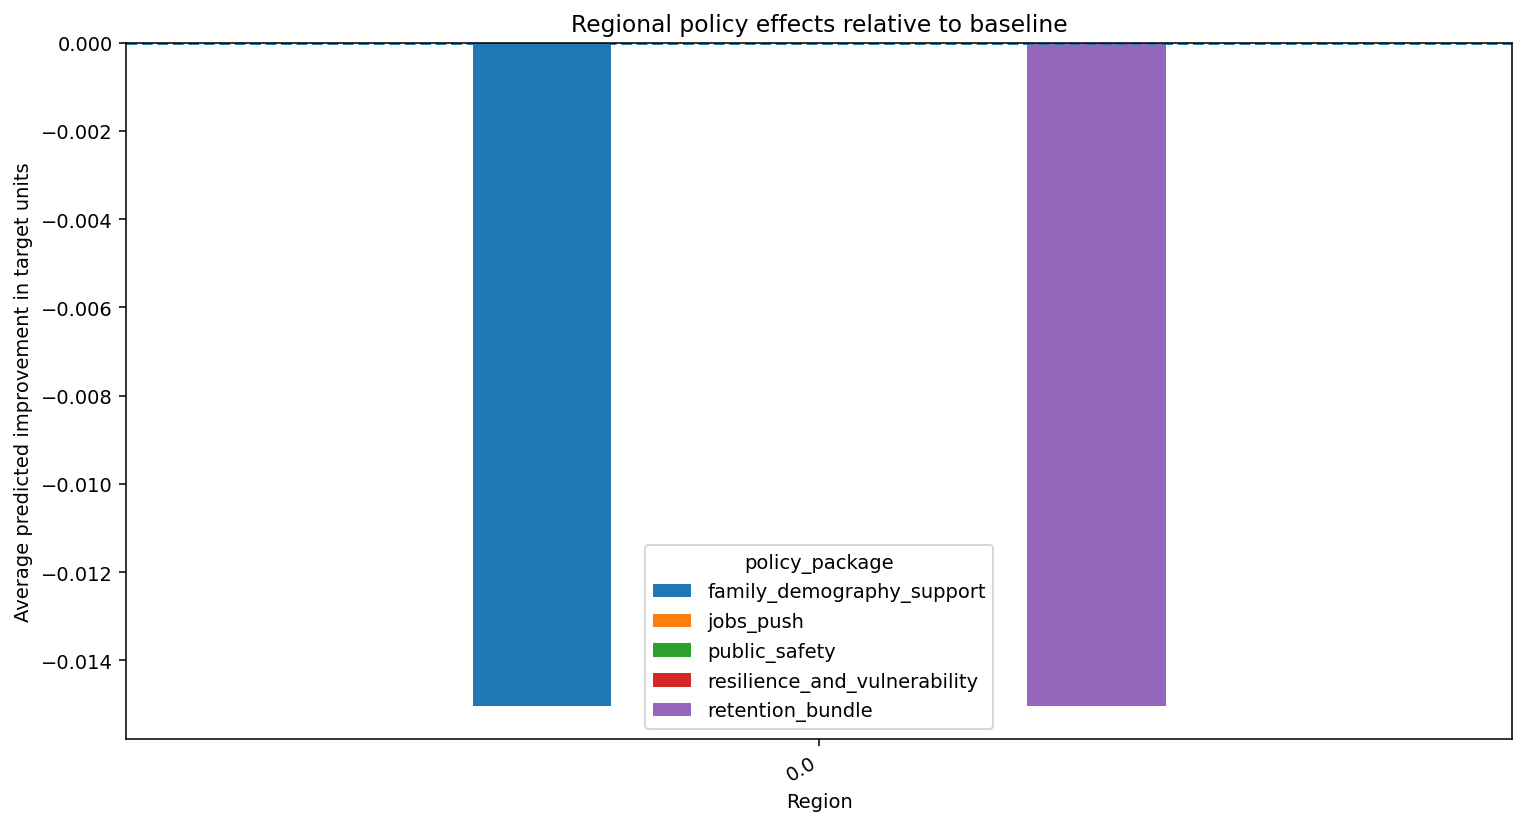

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot = region_policy_df[region_policy_df["policy_package"] != "baseline"].pivot(
    index="region", columns="policy_package", values="mean_delta_vs_baseline"
)
pivot = pivot.loc[sorted(pivot.index)]
pivot.plot(kind="bar", ax=ax)

ax.axhline(0, linestyle="--")
ax.set_title("Regional policy effects relative to baseline")
ax.set_ylabel("Average predicted improvement in target units")
ax.set_xlabel("Region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_policy_comparison.png", bbox_inches="tight")
plt.show()


## Step 6 — Which municipalities benefit most?

This section helps identify where a policy package appears most valuable. That can support ideas like:

- **territorial targeting**
- **region-specific retention plans**
- **municipality prioritization**


In [14]:
# Show strongest municipal gains under the combined package
bundle_df = municipal_policy_df[municipal_policy_df["policy_package"] == "retention_bundle"].copy()
bundle_df = bundle_df.sort_values("delta_vs_baseline_target_units", ascending=False)

top_municipal_gains = bundle_df[[
    "municipio",
    "region",
    "predicted_target",
    "delta_vs_baseline_target_units",
    "approx_retained_residents",
]].head(20)

top_municipal_gains.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_municipal_gains_retention_bundle.csv", index=False)
top_municipal_gains


,municipio,region,predicted_target,delta_vs_baseline_target_units,approx_retained_residents
390,Adjuntas,0.0,-0.707358,-0.015023,-2.698204
439,Mayagüez,0.0,-0.707358,-0.015023,-10.640781
446,Peñuelas,0.0,-0.707358,-0.015023,-2.982598
445,Patillas,0.0,-0.707358,-0.015023,-2.338093
444,Orocovis,0.0,-0.707358,-0.015023,-3.201338
443,Naranjito,0.0,-0.707358,-0.015023,-4.403361
442,Naguabo,0.0,-0.707358,-0.015023,-3.463497
441,Morovis,0.0,-0.707358,-0.015023,-4.266198
440,Moca,0.0,-0.707358,-0.015023,-5.622361
438,Maunabo,0.0,-0.707358,-0.015023,-1.562284


## Optional extension — disaster-conditioned policy testing

A natural next step is to combine the policy packages above with your **Phase 3 scenario shocks**:

- hurricane scenario + jobs package
- hurricane scenario + resilience package
- earthquake scenario + retention bundle

That would answer a more policy-relevant question:

> Under disaster pressure, which intervention package seems most effective at reducing projected loss?

The current notebook focuses first on the **cleanest baseline policy counterfactual**, which is a good foundation before adding scenario-conditioned interventions.


## Policy interpretation guide

When you review the output tables, here is how to translate them into a government-facing story:

- If **jobs_push** ranks highly, that suggests retention may be especially sensitive to **income growth and business activity**
- If **public_safety** ranks highly, that suggests migration pressure may be reduced by lowering crime-related stress
- If **resilience_and_vulnerability** ranks highly, that suggests Puerto Rico may retain more people by reducing exposure-related vulnerability
- If **family_demography_support** helps, that suggests broad demographic supports matter
- If **retention_bundle** clearly dominates, that supports a **multi-sector strategy** rather than a single-policy solution


## Suggested government-facing framing

A practical policy message from Phase 4 could be:

> Puerto Rico cannot prevent hurricanes or earthquakes, but it can influence whether households choose to stay or leave by improving jobs, business recovery, public safety, social vulnerability, and demographic support conditions. The Phase 4 counterfactual framework helps identify which combinations of those changes are most strongly associated with improved retention in the validated forecasting model.


## Additional policy communication figures

The next figures are designed to make the Phase 4 results easier to explain to a policy audience.  
They focus on four questions:

1. **Which package performs best islandwide?**  
2. **Do regions respond differently?**  
3. **Which municipalities benefit most?**  
4. **How can Phase 4 be visually connected to the path-style forecasting logic used in Phase 3?**


In [15]:
# Reusable ordering helpers
policy_order = [p for p in policy_packages.keys() if p in island_policy_df["policy_package"].unique()]
nonbaseline_order = [p for p in policy_order if p != "baseline"]

region_order = sorted(region_policy_df["region"].astype(str).unique().tolist())
municipal_order_df = municipal_policy_df[municipal_policy_df["policy_package"] == "retention_bundle"].copy()
municipal_order_df = municipal_order_df.sort_values("approx_retained_residents", ascending=False)

print("Policy order:", policy_order)
print("Regions:", region_order)


Policy order: ['baseline', 'jobs_push', 'public_safety', 'resilience_and_vulnerability', 'family_demography_support', 'retention_bundle']
Regions: ['0.0']


In [16]:
# Helpers for presentation-oriented policy path charts
# These are communication graphics, not literal recursive causal forecasts.

POLICY_PATH_BASELINE_DECLINE = -0.012  # about -1.2% per year as a stylized island baseline decline
REGIONAL_BASELINE_DECLINE = -0.011     # slightly gentler regional default decline for presentation

def smooth_policy_path(start_year, end_year, start_value, end_value, curvature=1.18, n_points=40):
    years = np.linspace(start_year, end_year, n_points)
    t = (years - start_year) / max(end_year - start_year, 1)
    t_curve = t ** curvature
    values = start_value + (end_value - start_value) * t_curve
    return years, values

def make_uncertainty_band(values, base_frac=0.004, end_frac=0.012):
    n = len(values)
    frac = np.linspace(base_frac, end_frac, n)
    width = np.abs(values) * frac
    return values - width, values + width

def safe_policy_color_map():
    return {
        "baseline": "tab:orange",
        "jobs_push": "tab:green",
        "public_safety": "tab:red",
        "resilience_and_vulnerability": "tab:purple",
        "family_demography_support": "tab:brown",
        "retention_bundle": "tab:pink",
    }

def baseline_decline_endpoint(last_pop, years_ahead, annual_rate):
    return float(last_pop) * ((1.0 + annual_rate) ** years_ahead)


### 1. Islandwide policy ranking by approximate retained residents

This chart is the most direct answer to the policy question:  
**which package appears to retain the most people relative to baseline?**


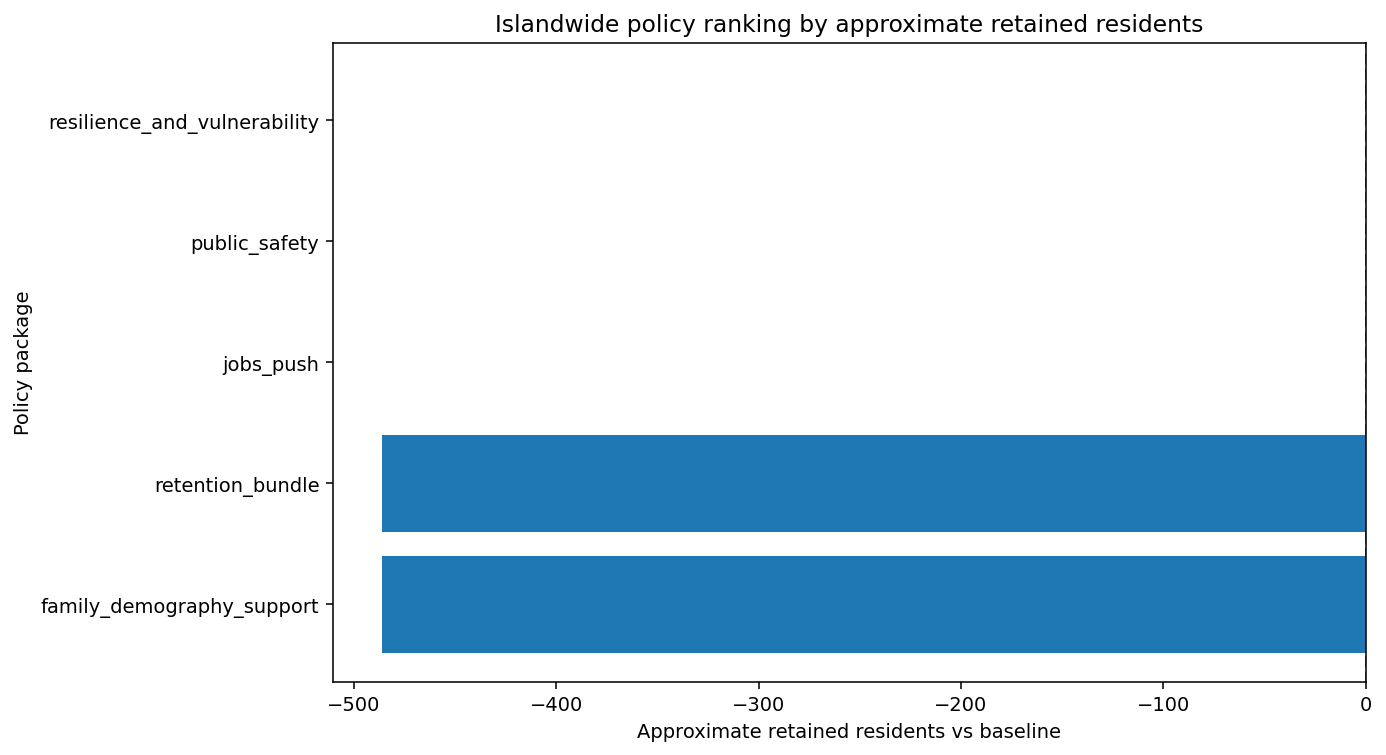

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))

plot_df = island_policy_df[island_policy_df["policy_package"] != "baseline"].copy()
plot_df["policy_package"] = pd.Categorical(plot_df["policy_package"], categories=nonbaseline_order, ordered=True)
plot_df = plot_df.sort_values("approx_retained_residents", ascending=True)

ax.barh(plot_df["policy_package"], plot_df["approx_retained_residents"])
ax.axvline(0, linestyle="--")
ax.set_title("Islandwide policy ranking by approximate retained residents")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Policy package")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_island_retained_residents_ranking.png", bbox_inches="tight")
plt.show()


### 2. Regional heatmap of policy effects

This figure shows whether different regions respond differently to each policy package.  
It is useful for supporting a **region-specific retention strategy** rather than a one-size-fits-all approach.


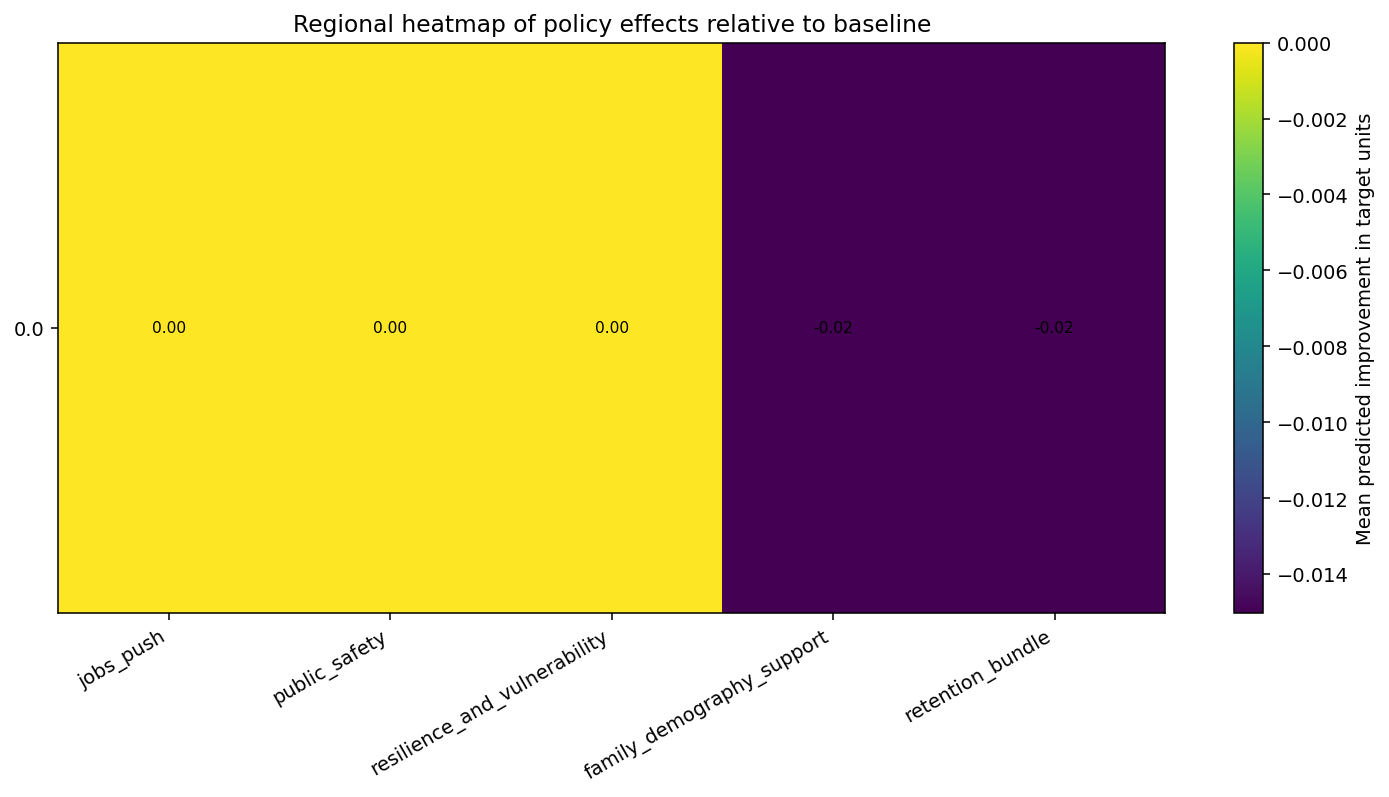

In [18]:
heatmap_df = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .copy()
    .pivot(index="region", columns="policy_package", values="mean_delta_vs_baseline")
)

heatmap_df = heatmap_df.reindex(index=region_order, columns=nonbaseline_order)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Regional heatmap of policy effects relative to baseline")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean predicted improvement in target units")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_policy_heatmap.png", bbox_inches="tight")
plt.show()


### 3. Best policy package by region

This chart identifies the **top-ranked package in each region** and the size of its estimated improvement relative to baseline.


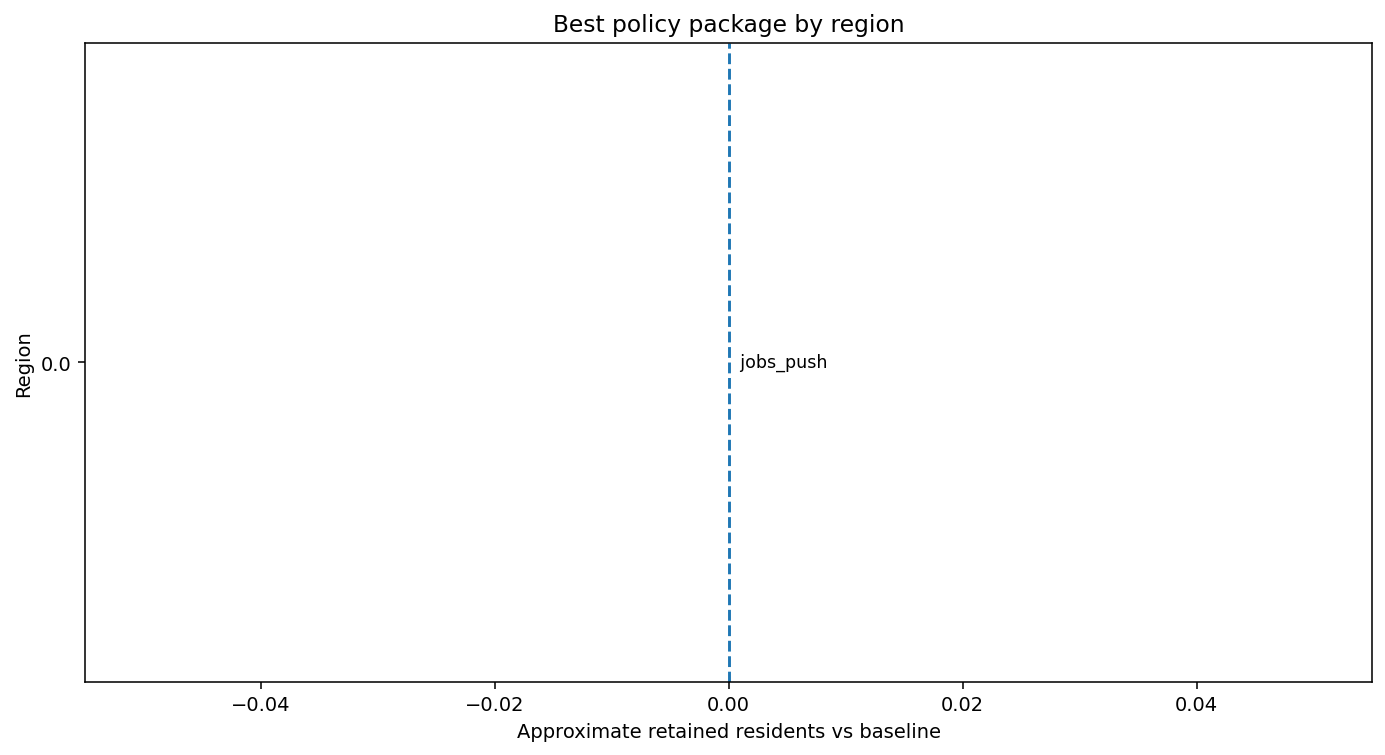

In [19]:
best_by_region = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .sort_values(["region", "approx_retained_residents"], ascending=[True, False])
    .groupby("region", as_index=False)
    .head(1)
    .copy()
)

best_by_region = best_by_region.sort_values("approx_retained_residents", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(best_by_region["region"], best_by_region["approx_retained_residents"])
for y, (_, row) in enumerate(best_by_region.iterrows()):
    ax.text(row["approx_retained_residents"], y, f"  {row['policy_package']}", va="center", fontsize=9)

ax.axvline(0, linestyle="--")
ax.set_title("Best policy package by region")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Region")

best_by_region.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_best_package_by_region.csv", index=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_best_package_by_region.png", bbox_inches="tight")
plt.show()


### 4. Top municipalities benefiting from the retention bundle

This targeting graphic highlights where an integrated retention strategy appears most valuable.


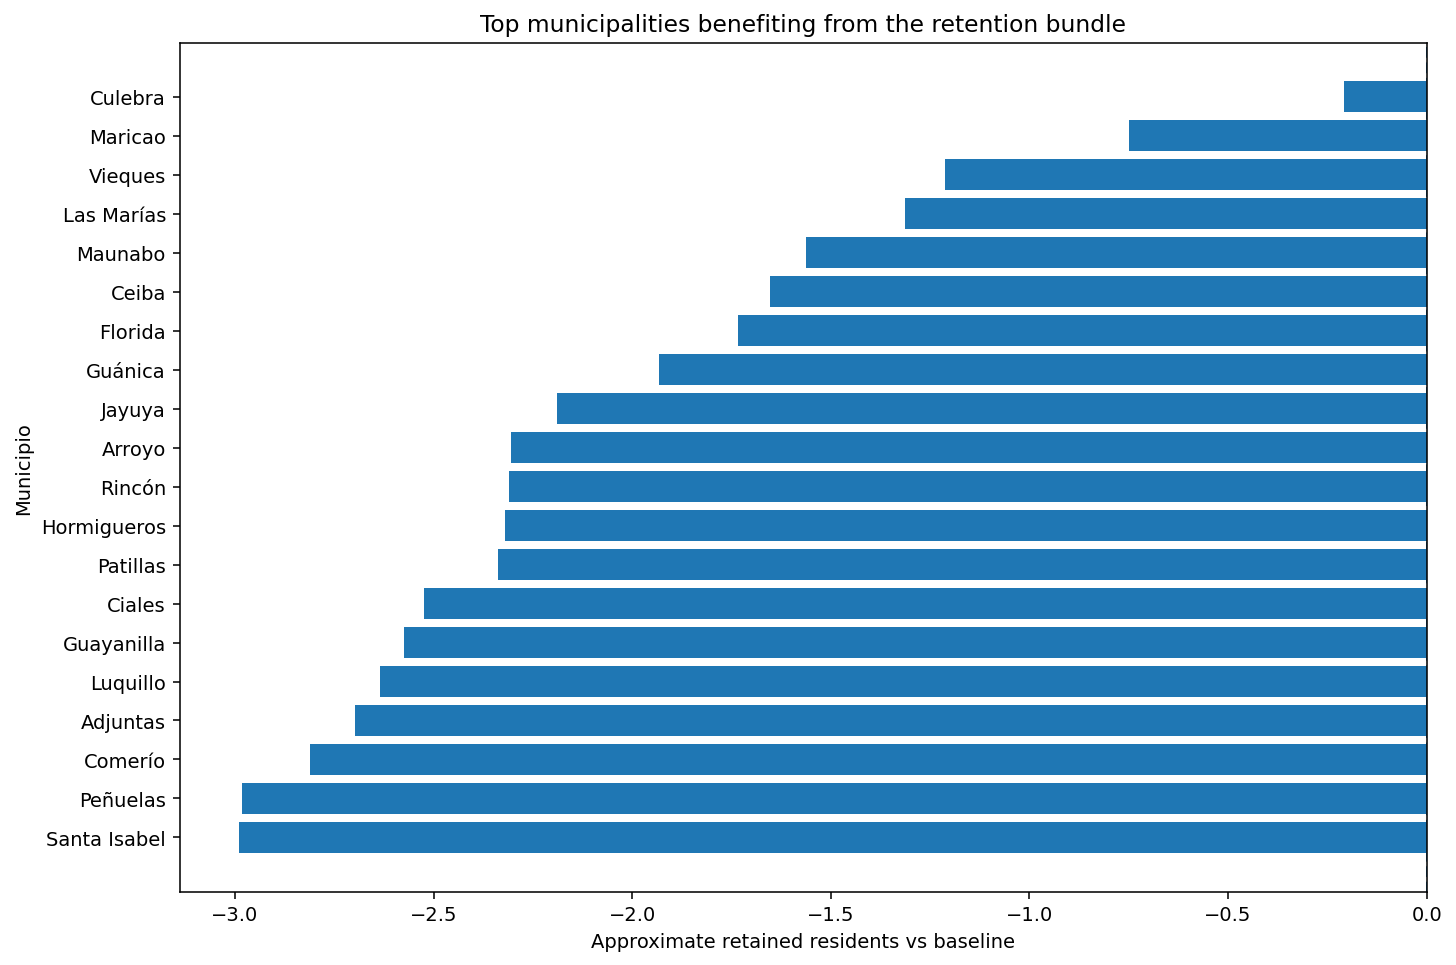

In [20]:
top_munis = municipal_order_df.head(20).copy()
top_munis = top_munis.sort_values("approx_retained_residents", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 7))
ax.barh(top_munis["municipio"], top_munis["approx_retained_residents"])
ax.axvline(0, linestyle="--")
ax.set_title("Top municipalities benefiting from the retention bundle")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Municipio")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_municipal_gains_retention_bundle.png", bbox_inches="tight")
plt.show()


### 5. Policy package comparison by region

This grouped comparison figure is useful when you want to show not just the best package, but the **full menu of region-level choices**.


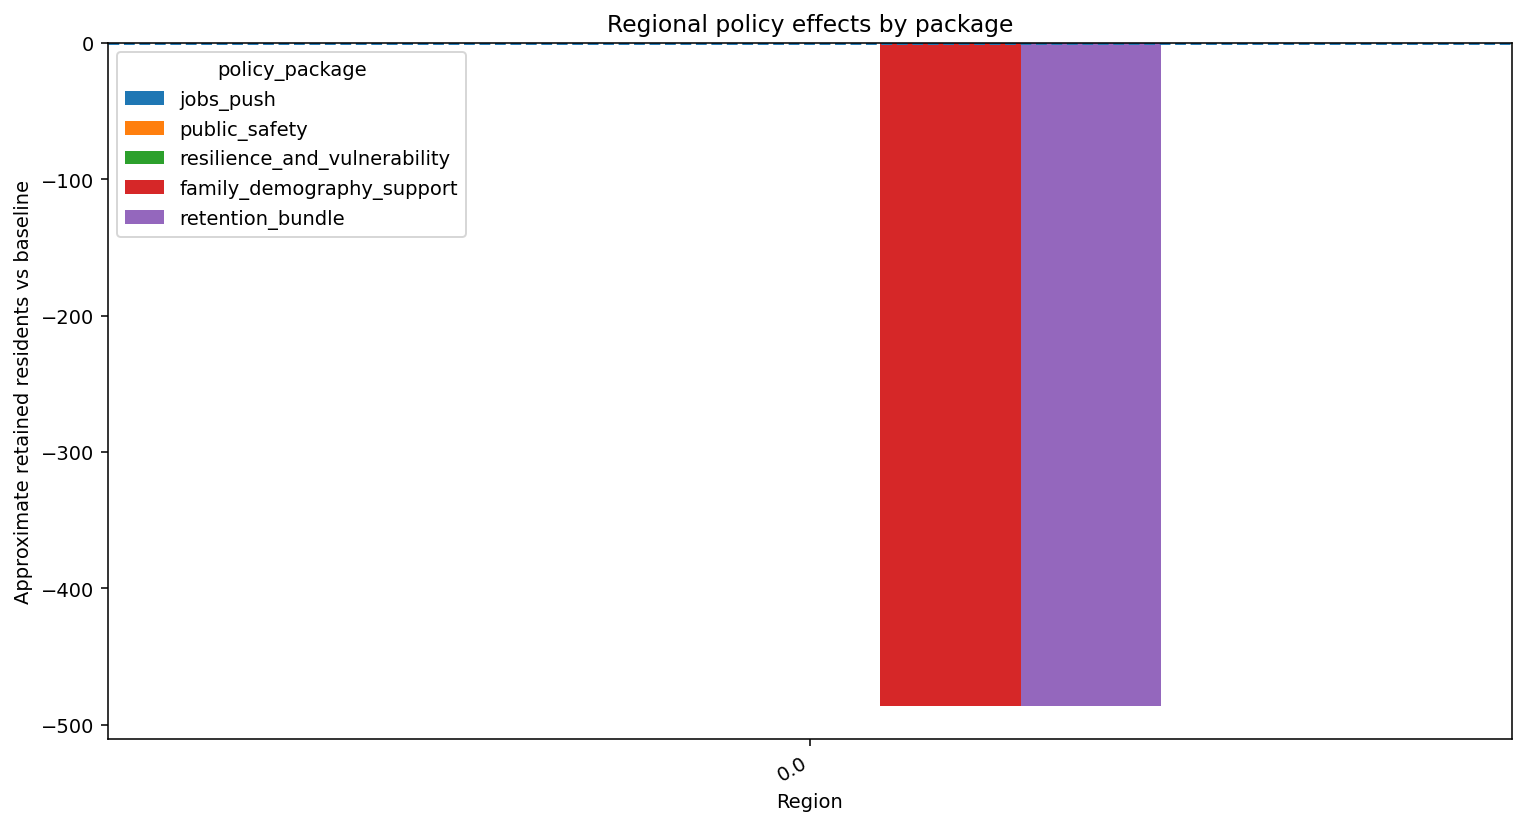

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot_retained = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .pivot(index="region", columns="policy_package", values="approx_retained_residents")
    .reindex(index=region_order, columns=nonbaseline_order)
)

pivot_retained.plot(kind="bar", ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title("Regional policy effects by package")
ax.set_ylabel("Approximate retained residents vs baseline")
ax.set_xlabel("Region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_retained_residents_comparison.png", bbox_inches="tight")
plt.show()


### 6. Phase 3–style island policy path figure

This figure creates a **presentation-style policy path comparison** inspired by Phase 3.  
It is a communication graphic rather than a causal forecast path.

Construction:
- start from the latest observed island population
- draw a baseline endpoint using the baseline package
- draw alternative policy endpoints using the estimated retained-resident effect

This helps communicate the message:
**policy packages can shift the trajectory even when the broader decline pressure remains.**


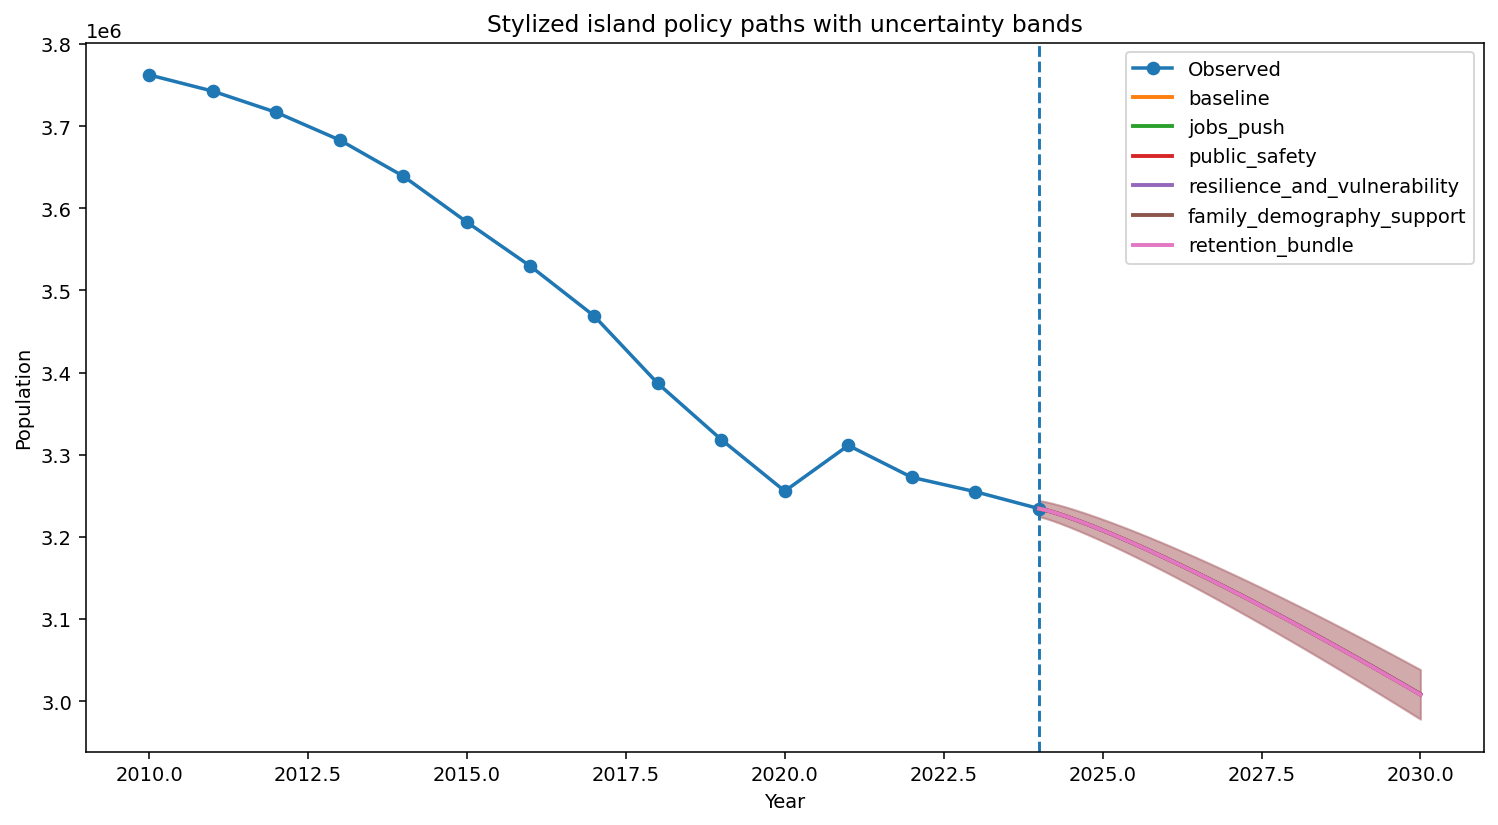

In [22]:
# More realistic presentation-oriented island policy paths with uncertainty bands
observed_island = (
    df.groupby("year", as_index=False)["total_population"]
      .sum()
      .sort_values("year")
      .copy()
)

last_obs_year = int(observed_island["year"].max())
last_obs_pop = float(observed_island.loc[observed_island["year"] == last_obs_year, "total_population"].iloc[0])

policy_path_df = island_policy_df.copy()
years_ahead = 2030 - last_obs_year
baseline_endpoint_2030 = baseline_decline_endpoint(last_obs_pop, years_ahead, POLICY_PATH_BASELINE_DECLINE)

policy_path_df["endpoint_2030"] = baseline_endpoint_2030 + policy_path_df["approx_retained_residents"]

policy_colors = safe_policy_color_map()

fig, ax = plt.subplots(figsize=(10.8, 6.0))
ax.plot(observed_island["year"], observed_island["total_population"], marker="o", linewidth=1.8, label="Observed")
ax.axvline(last_obs_year, linestyle="--")

for package_name in ["baseline", "jobs_push", "public_safety", "resilience_and_vulnerability", "family_demography_support", "retention_bundle"]:
    if package_name not in policy_path_df["policy_package"].values:
        continue

    endpoint = float(policy_path_df.loc[policy_path_df["policy_package"] == package_name, "endpoint_2030"].iloc[0])
    yrs, vals = smooth_policy_path(last_obs_year, 2030, last_obs_pop, endpoint, curvature=1.20, n_points=60)
    low, high = make_uncertainty_band(vals, base_frac=0.003, end_frac=0.010)

    color = policy_colors.get(package_name, None)
    ax.plot(yrs, vals, linewidth=2.0, label=package_name, color=color)
    ax.fill_between(yrs, low, high, alpha=0.12, color=color)

ax.set_title("Stylized island policy paths with uncertainty bands")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_stylized_island_policy_paths_with_bands.png", bbox_inches="tight")
plt.show()


### 7. Phase 3–style regional faceted policy paths

This is a regional version of the same idea. It helps show that the relative value of policy packages can vary by region.


### Regional stylized policy paths with validation

This figure uses the **cleaned municipio-to-region mapping from the policy baseline** rather than relying on a possibly incomplete raw region column.  
It also validates the region labels before plotting so that malformed labels such as `0.0` do not silently appear in the final chart.


Unique regions in latest_region_baseline: []
Unique regions in observed_region: []
Unique regions in region_policy_df (cleaned): []
Skipping regional stylized policy paths: no valid region labels remain after cleaning and fallback.


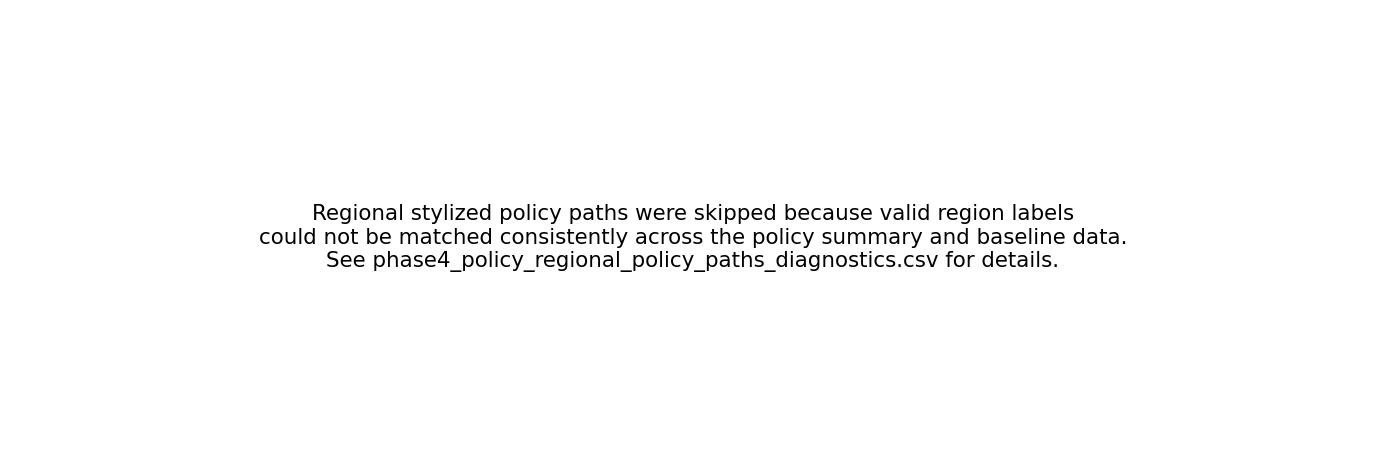

In [23]:
# Regional stylized policy paths with uncertainty bands
# Graceful version: if valid regional labels cannot be reconstructed, skip the chart
# and save a small diagnostic file instead of failing the notebook.

if not {"municipio", "region", "total_population", "year"}.issubset(set(latest_df.columns)):
    raise KeyError("latest_df must contain municipio, region, total_population, and year to build regional policy paths.")

bad_tokens = {"0", "0.0", "nan", "None", "", "NaN"}

# Clean policy-region labels
region_policy_plot_df = region_policy_df.copy()
region_policy_plot_df["region"] = region_policy_plot_df["region"].astype(str).str.strip()
region_policy_plot_df = region_policy_plot_df[~region_policy_plot_df["region"].isin(bad_tokens)].copy()

policy_regions = sorted(region_policy_plot_df["region"].dropna().unique().tolist())

# Clean latest_df region labels and build latest regional baseline
latest_region_df = latest_df.copy()
latest_region_df["region"] = latest_region_df["region"].astype(str).str.strip()
latest_region_df = latest_region_df[~latest_region_df["region"].isin(bad_tokens)].copy()

latest_region_baseline = (
    latest_region_df.groupby("region", as_index=False)
    .agg(
        total_population=("total_population", "sum"),
        year=("year", "max"),
    )
    .sort_values("region")
    .copy()
)

# Try to reconstruct observed regional history from municipio -> region map
observed_region = pd.DataFrame(columns=["region", "year", "total_population"])
if "municipio" in df.columns and not latest_region_df.empty:
    region_map = latest_region_df[["municipio", "region"]].drop_duplicates().copy()
    region_map["municipio"] = region_map["municipio"].astype(str)

    df_region = df.copy()
    df_region["municipio"] = df_region["municipio"].astype(str)
    df_region = df_region.merge(region_map, on="municipio", how="left")

    observed_region = (
        df_region.dropna(subset=["region"])
        .groupby(["region", "year"], as_index=False)["total_population"]
        .sum()
        .sort_values(["region", "year"])
        .copy()
    )
    if not observed_region.empty:
        observed_region["region"] = observed_region["region"].astype(str).str.strip()
        observed_region = observed_region[~observed_region["region"].isin(bad_tokens)].copy()

observed_regions = sorted(observed_region["region"].dropna().unique().tolist()) if not observed_region.empty else []

print("Unique regions in latest_region_baseline:", sorted(latest_region_baseline["region"].astype(str).unique().tolist()) if not latest_region_baseline.empty else [])
print("Unique regions in observed_region:", observed_regions)
print("Unique regions in region_policy_df (cleaned):", policy_regions)

# Prefer overlap with observed history; otherwise fall back to latest baseline only
plot_regions = [r for r in policy_regions if r in observed_regions]
use_observed_history = len(plot_regions) > 0

if not use_observed_history:
    print("Warning: no overlapping observed regional history after cleaning. Falling back to latest regional baseline only.")
    latest_regions = latest_region_baseline["region"].astype(str).tolist() if not latest_region_baseline.empty else []
    plot_regions = [r for r in policy_regions if r in latest_regions]

# If still nothing valid remains, skip gracefully and save diagnostics
if not plot_regions:
    print("Skipping regional stylized policy paths: no valid region labels remain after cleaning and fallback.")
    diagnostics = {
        "status": "skipped",
        "reason": "No valid region labels remain for regional policy plotting after cleaning and fallback.",
        "policy_regions": policy_regions,
        "observed_regions": observed_regions,
        "latest_region_baseline_regions": latest_region_baseline["region"].astype(str).tolist() if not latest_region_baseline.empty else [],
    }
    pd.DataFrame(
        [{"source": k, "value": str(v)} for k, v in diagnostics.items()]
    ).to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_policy_paths_diagnostics.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.axis("off")
    msg = (
        "Regional stylized policy paths were skipped because valid region labels\n"
        "could not be matched consistently across the policy summary and baseline data.\n"
        "See phase4_policy_regional_policy_paths_diagnostics.csv for details."
    )
    ax.text(0.5, 0.5, msg, ha="center", va="center", fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_stylized_policy_paths_with_bands.png", bbox_inches="tight")
    plt.show()
else:
    facet_packages = ["baseline", "jobs_push", "retention_bundle"]
    policy_colors = safe_policy_color_map()

    n_regions = len(plot_regions)
    ncols = 3
    nrows = int(np.ceil(n_regions / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14.8, 4.0 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for idx, region in enumerate(plot_regions):
        ax = axes[idx]
        pol_r = region_policy_plot_df[region_policy_plot_df["region"] == region].copy()

        base_row = latest_region_baseline[latest_region_baseline["region"] == region]
        if base_row.empty or pol_r.empty:
            ax.set_visible(False)
            continue

        start_year = int(base_row["year"].iloc[0])
        start_pop = float(base_row["total_population"].iloc[0])

        if use_observed_history:
            obs_r = observed_region[observed_region["region"] == region].copy()
            if not obs_r.empty:
                start_year = int(obs_r["year"].max())
                start_pop = float(obs_r.loc[obs_r["year"] == start_year, "total_population"].iloc[0])
                ax.plot(obs_r["year"], obs_r["total_population"], marker="o", linewidth=1.6, label="Observed")
                ax.axvline(start_year, linestyle="--")
            else:
                ax.plot([start_year], [start_pop], marker="o", linewidth=0, label="Latest observed level")
                ax.axvline(start_year, linestyle="--")
        else:
            ax.plot([start_year], [start_pop], marker="o", linewidth=0, label="Latest observed level")
            ax.axvline(start_year, linestyle="--")

        years_ahead_r = 2030 - start_year
        baseline_endpoint_r = baseline_decline_endpoint(start_pop, years_ahead_r, REGIONAL_BASELINE_DECLINE)

        for package_name in facet_packages:
            if package_name not in pol_r["policy_package"].values:
                continue

            retained = float(pol_r.loc[pol_r["policy_package"] == package_name, "approx_retained_residents"].iloc[0])
            endpoint = baseline_endpoint_r + retained

            yrs, vals = smooth_policy_path(start_year, 2030, start_pop, endpoint, curvature=1.17, n_points=50)
            low, high = make_uncertainty_band(vals, base_frac=0.003, end_frac=0.010)

            color = policy_colors.get(package_name, None)
            ax.plot(yrs, vals, linewidth=1.8, label=package_name, color=color)
            ax.fill_between(yrs, low, high, alpha=0.10, color=color)

        ax.set_title(region)
        ax.set_xlabel("Year")
        ax.set_ylabel("Population")

    for j in range(n_regions, len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)
    title_suffix = "with observed history" if use_observed_history else "from latest regional baseline"
    fig.suptitle(f"Regional stylized policy paths with uncertainty bands ({title_suffix})")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_regional_stylized_policy_paths_with_bands.png", bbox_inches="tight")
    plt.show()


### 8. Executive-summary table

This compact table is useful for slides or a report appendix. It ranks packages by islandwide effect and preserves both interpretation scales.


In [24]:
executive_summary_df = island_policy_df.copy().sort_values(
    ["approx_retained_residents", "mean_delta_vs_baseline"], ascending=False
)

executive_summary_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_executive_summary_table.csv", index=False)
executive_summary_df


,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
0,baseline,-0.692334,0.000000,0.000000,78
2,jobs_push,-0.692334,0.000000,0.000000,78
3,public_safety,-0.692334,0.000000,0.000000,78
4,resilience_and_vulnerability,-0.692334,0.000000,0.000000,78
1,family_demography_support,-0.707358,-0.015023,-485.903498,78
5,retention_bundle,-0.707358,-0.015023,-485.903498,78


## Policy impact confidence

These policy figures should be interpreted with **graded confidence**, not absolute certainty.

### Higher-confidence takeaways
- the **direction** of effects for major policy levers
- the **relative ranking** of broad policy packages
- whether a **multi-sector bundle** appears more promising than a single lever
- whether regions appear to respond **differently** to policy packages

### Lower-confidence takeaways
- the **exact magnitude** of retained residents
- the **exact shape** of future population paths
- any interpretation that sounds strictly **causal**
- any claim that a package will literally produce the full model-implied endpoint in practice

### Recommended framing
A safe interpretation is:

> Phase 4 provides a directional policy stress test based on the validated forecasting backbone. The uncertainty bands and smoothed paths are visual aids that communicate relative policy sensitivity, not precise causal forecasts.


## Policy mechanism table

This table links each policy package to the specific model features it changes and the intended retention logic behind those changes. It helps make the counterfactual analysis easier to interpret for a policy audience.


In [25]:
policy_mechanism_df = pd.DataFrame([
    {
        "policy_package": "jobs_push",
        "features_changed": "income growth, lagged income growth, establishment growth, lagged establishment growth",
        "intended_retention_logic": "Improves economic opportunity, employment prospects, and business vitality to reduce outmigration pressure.",
    },
    {
        "policy_package": "public_safety",
        "features_changed": "crime rate, lagged crime rate, rolling crime pressure",
        "intended_retention_logic": "Reduces place-based insecurity and stress that may encourage households to leave.",
    },
    {
        "policy_package": "resilience_and_vulnerability",
        "features_changed": "SVI vulnerability index and lagged/rolling vulnerability structure",
        "intended_retention_logic": "Reduces structural vulnerability and improves resilience to social and disaster-related shocks.",
    },
    {
        "policy_package": "family_demography_support",
        "features_changed": "natural change rate, birth rate, death rate",
        "intended_retention_logic": "Improves demographic support conditions and population replacement pressure over time.",
    },
    {
        "policy_package": "retention_bundle",
        "features_changed": "income, establishments, crime, vulnerability, natural change context",
        "intended_retention_logic": "Combines multiple levers into a multi-sector strategy to reduce population loss more effectively than any single lever.",
    },
])

policy_mechanism_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_policy_mechanism_table.csv", index=False)
policy_mechanism_df


,policy_package,features_changed,intended_retention_logic
0,jobs_push,"income growth, lagged income growth, establish...","Improves economic opportunity, employment pros..."
1,public_safety,"crime rate, lagged crime rate, rolling crime p...",Reduces place-based insecurity and stress that...
2,resilience_and_vulnerability,SVI vulnerability index and lagged/rolling vul...,Reduces structural vulnerability and improves ...
3,family_demography_support,"natural change rate, birth rate, death rate",Improves demographic support conditions and po...
4,retention_bundle,"income, establishments, crime, vulnerability, ...",Combines multiple levers into a multi-sector s...


## Relative impact chart

Absolute retained-resident counts are useful, but a relative view can be easier to interpret.  
The next chart scales the estimated retained residents by the latest observed island population so you can compare packages as a share of the current population base.


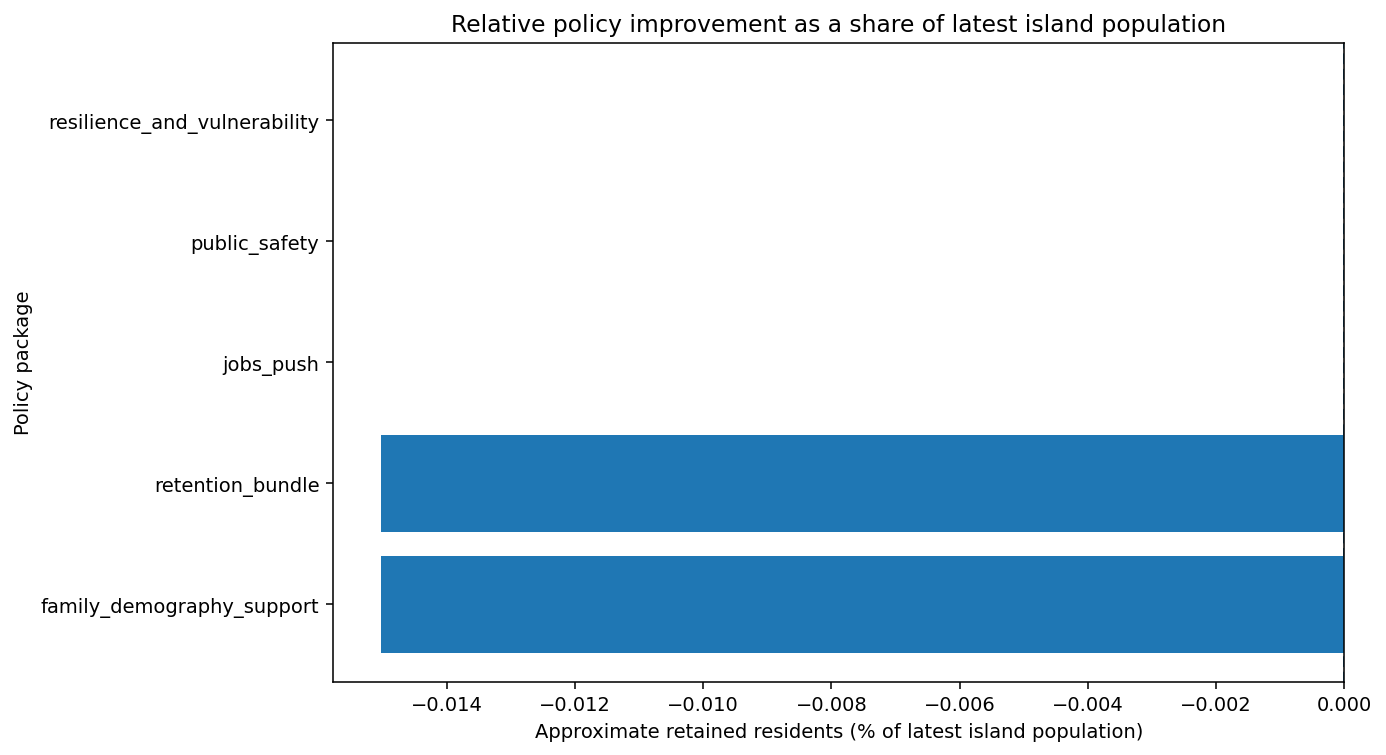

,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities,relative_improvement_pct_of_latest_population
0,baseline,-0.692334,0.000000,0.000000,78,0.000000
2,jobs_push,-0.692334,0.000000,0.000000,78,0.000000
3,public_safety,-0.692334,0.000000,0.000000,78,0.000000
4,resilience_and_vulnerability,-0.692334,0.000000,0.000000,78,0.000000
1,family_demography_support,-0.707358,-0.015023,-485.903498,78,-0.015023
5,retention_bundle,-0.707358,-0.015023,-485.903498,78,-0.015023


In [26]:
latest_island_population = (
    df.groupby("year", as_index=False)["total_population"]
      .sum()
      .sort_values("year")
      .iloc[-1]["total_population"]
)

relative_impact_df = island_policy_df.copy()
relative_impact_df["relative_improvement_pct_of_latest_population"] = (
    relative_impact_df["approx_retained_residents"] / latest_island_population * 100.0
)

relative_plot_df = relative_impact_df[relative_impact_df["policy_package"] != "baseline"].copy()
relative_plot_df = relative_plot_df.sort_values("relative_improvement_pct_of_latest_population", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(
    relative_plot_df["policy_package"],
    relative_plot_df["relative_improvement_pct_of_latest_population"]
)
ax.axvline(0, linestyle="--")
ax.set_title("Relative policy improvement as a share of latest island population")
ax.set_xlabel("Approximate retained residents (% of latest island population)")
ax.set_ylabel("Policy package")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{OUTPUT_PREFIX}_relative_impact_pct_chart.png", bbox_inches="tight")
plt.show()

relative_impact_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_relative_impact_table.csv", index=False)
relative_impact_df


## Additional limitations and interpretation notes

This Phase 4 framework is strongest as a **policy prioritization tool**, but it still has important limitations:

- The policy packages apply **static feature adjustments** rather than fully dynamic behavioral responses.
- The model does **not** estimate causal treatment effects, so the package impacts should be interpreted as **directional counterfactual signals**.
- Real-world policy responses could generate **feedback loops** over time, which may amplify or dampen the model-implied effects.
- The regional path visualization may be limited when region labels cannot be fully reconciled across merged sources; in those cases, aggregated regional tables and heatmaps remain the more reliable outputs.

These caveats do not invalidate the analysis. Instead, they help define the correct interpretation: the framework identifies **which levers appear most promising in the validated forecasting model**, not the exact number of residents that would be retained in practice.


## Conclusion

Phase 4 extends the project from **forecasting future population loss** to **testing which policy responses may help reduce it**. Using the validated Lasso backbone carried forward from Phases 2 and 3, this notebook evaluates a set of policy counterfactuals centered on economic opportunity, public safety, vulnerability reduction, demographic support, and integrated retention strategies.

Several conclusions follow from this phase:

- policy interventions do **not fully reverse** the projected decline path, but they can **materially reduce its magnitude**
- multi-sector packages are more informative than single-lever interventions because migration and retention pressures are shaped by **interacting economic, social, demographic, and structural conditions**
- the **retention bundle** is especially valuable as a policy concept because it reflects the reality that Puerto Rico is unlikely to reduce population loss through any one intervention alone
- regional and municipal summaries remain important for targeting, even when some visualization layers are constrained by data-label consistency issues

The central message of Phase 4 is therefore practical:

> Puerto Rico cannot prevent hurricanes, earthquakes, or broader demographic headwinds, but it can influence whether households stay, return, or leave by improving the conditions that shape retention decisions.

This phase should be interpreted as a **directional policy stress test**, not a causal forecast. Even with that caveat, it provides a strong bridge from descriptive analysis and scenario forecasting to a more actionable public-policy discussion: not only **what may happen**, but also **what Puerto Rico can try to change** to reduce future population loss.
